#**[ГИТХАБ](https://github.com/Torentine/colab-timeseries-notebooks)**

# Анализ временного ряда ETTh1

Ноутбук подготовлен для Google Colab и GitHub. Он показывает все результаты внутри ячеек: таблицы, метрики и графики. Файлы в папки не сохраняются.


## Запуск в Google Colab

Сначала выполните ячейку ниже, затем запускайте ноутбук сверху вниз.


In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip -q install pandas numpy matplotlib scikit-learn statsmodels

print("Среда готова.")


Среда готова.


## Импорты и загрузка данных


In [3]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

# Игнорирование предупреждений для более чистого вывода
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

# Определение путей и URL для данных
LOCAL_DATA = Path("data/etth1_ot_prepared.csv") # Локальный путь к подготовленным данным
ETTH1_URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv" # URL для загрузки данных ETTh1
RANDOM_STATE = 42 # Фиксированный "random state" для воспроизводимости результатов


def load_etth1():
    # Функция для загрузки данных ETTh1
    if LOCAL_DATA.exists():
        # Если локальный файл существует, загружаем его
        df = pd.read_csv(LOCAL_DATA)
        source = str(LOCAL_DATA)
    else:
        # В противном случае, загружаем данные с GitHub
        raw = pd.read_csv(ETTH1_URL)
        # Выбираем только столбцы 'date' и 'OT' и переименовываем их в 'ds' и 'y'
        df = raw[["date", "OT"]].rename(columns={"date": "ds", "OT": "y"})
        source = ETTH1_URL

    # Преобразование столбца 'ds' в формат datetime
    df["ds"] = pd.to_datetime(df["ds"])
    # Преобразование столбца 'y' в числовой формат, ошибки преобразуются в NaN
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    # Удаление строк с NaN в 'ds' или 'y', сортировка по 'ds' и удаление дубликатов
    df = df.dropna(subset=["ds", "y"]).sort_values("ds").drop_duplicates("ds")
    # Выбираем последние 3500 строк и сбрасываем индекс
    df = df.tail(3500).reset_index(drop=True)
    return df, source


df, source = load_etth1() # Загрузка данных и получение информации об источнике
print(f"Источник данных: {source}") # Вывод источника данных
print(f"Размер ряда: {df.shape[0]} строк") # Вывод количества строк в данных
display(df.head()) # Отображение первых строк DataFrame

Источник данных: https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv
Размер ряда: 3500 строк


,ds,y
0,2018-02-01 00:00:00,2.744
1,2018-02-01 01:00:00,3.025
2,2018-02-01 02:00:00,3.025
3,2018-02-01 03:00:00,3.236
4,2018-02-01 04:00:00,2.884


## Проверка качества и EDA


,metric,value
0,start,2018-02-01 00:00:00
1,end,2018-06-26 19:00:00
2,rows,3500
3,missing_y,0
4,duplicate_dates,0
5,frequency_mode,0 days 01:00:00


,y
count,3500.000000
mean,7.701698
std,3.451383
min,-0.915000
25%,4.854000
50%,8.160000
75%,10.271000
max,17.165001


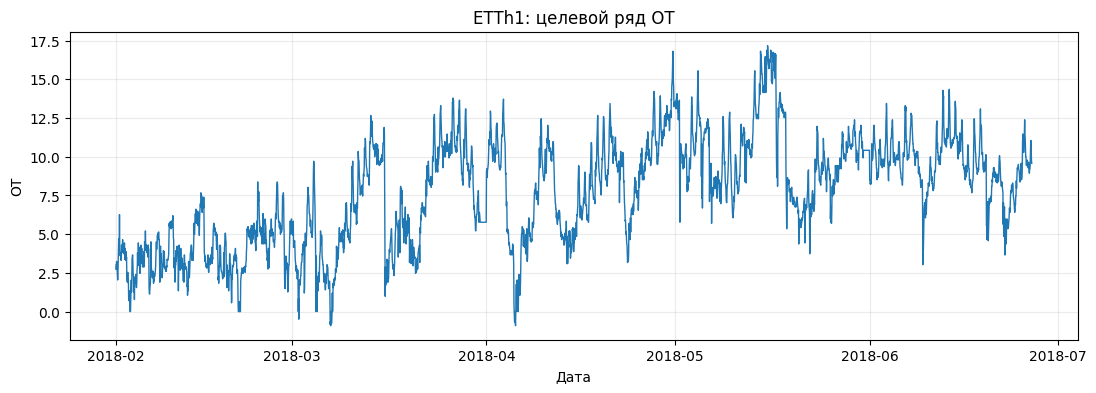

In [4]:
# Создание DataFrame для оценки качества данных
quality = pd.DataFrame({
    "metric": ["start", "end", "rows", "missing_y", "duplicate_dates", "frequency_mode"], # Метрики качества
    "value": [
        df["ds"].min(), # Минимальная дата в ряду
        df["ds"].max(), # Максимальная дата в ряду
        len(df), # Общее количество строк
        int(df["y"].isna().sum()), # Количество пропущенных значений в целевой переменной 'y'
        int(df["ds"].duplicated().sum()), # Количество продублированных дат
        df["ds"].diff().mode().iloc[0], # Модальная частота временного ряда
    ],
})
display(quality) # Отображение таблицы качества данных

# Отображение описательной статистики для целевой переменной 'y'
display(df["y"].describe().to_frame("y"))

# Построение графика временного ряда
fig, ax = plt.subplots(figsize=(13, 4)) # Создание фигуры и осей для графика
ax.plot(df["ds"], df["y"], linewidth=1) # Построение линии ряда
ax.set_title("ETTh1: целевой ряд OT") # Заголовок графика
ax.set_xlabel("Дата") # Подпись оси X
ax.set_ylabel("OT") # Подпись оси Y
ax.grid(alpha=0.25) # Добавление сетки на график
plt.show() # Отображение графика

Профиль по часам


,count,mean,std,min,max
hour,,,,,
0,146,7.305,3.237,0.774,16.109
1,146,7.239,3.292,0.000,16.602
2,146,7.249,3.199,0.563,16.109
3,146,7.187,3.109,-0.844,16.109
4,146,7.090,3.039,-0.633,16.250
5,146,7.058,3.070,-0.915,16.461
6,146,7.108,3.185,0.000,16.883
7,146,7.145,3.313,-0.492,16.672
8,146,7.295,3.430,-0.774,16.039


Профиль по дням недели


,count,mean,std,min,max
dayofweek,,,,,
0,504,8.059,3.579,0.000,16.813
1,500,8.159,3.801,0.000,17.165
2,480,8.109,3.668,-0.915,16.883
3,504,7.542,3.432,-0.915,16.602
4,504,7.293,3.390,-0.492,15.547
5,504,7.006,2.974,0.000,13.929
6,504,7.767,3.102,0.000,15.547


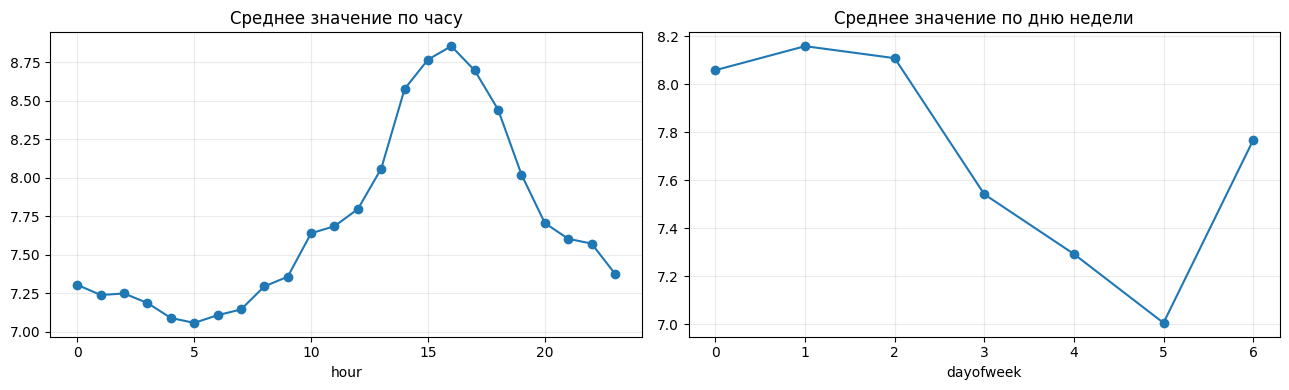

,series,adf_stat,p_value
0,original,-4.01358,0.00134
1,seasonal_diff_24,-8.37833,0.00000


In [5]:
# Копирование DataFrame для проведения EDA (Exploratory Data Analysis)
eda = df.copy()
# Извлечение часа из временной метки 'ds' и создание нового столбца 'hour'
eda["hour"] = eda["ds"].dt.hour
# Извлечение дня недели из временной метки 'ds' и создание нового столбца 'dayofweek' (0=понедельник, 6=воскресенье)
eda["dayofweek"] = eda["ds"].dt.dayofweek

# Группировка данных по часам и вычисление агрегированных статистик (количество, среднее, стандартное отклонение, мин, макс) для 'y'
hour_profile = eda.groupby("hour")["y"].agg(["count", "mean", "std", "min", "max"]).round(3)
# Группировка данных по дням недели и вычисление агрегированных статистик для 'y'
dow_profile = eda.groupby("dayofweek")["y"].agg(["count", "mean", "std", "min", "max"]).round(3)

# Вывод заголовка и таблицы профиля по часам
print("Профиль по часам")
display(hour_profile)
# Вывод заголовка и таблицы профиля по дням недели
print("Профиль по дням недели")
display(dow_profile)

# Создание фигуры и двух подграфиков для визуализации профилей
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# Построение графика среднего значения 'y' по часам
hour_profile["mean"].plot(ax=axes[0], marker="o", title="Среднее значение по часу")
# Построение графика среднего значения 'y' по дням недели
dow_profile["mean"].plot(ax=axes[1], marker="o", title="Среднее значение по дню недели")
# Добавление сетки на оба графика
for ax in axes:
    ax.grid(alpha=0.25)
# Автоматическая корректировка параметров подграфиков для плотного размещения
plt.tight_layout()
# Отображение графиков
plt.show()

# Выполнение расширенного теста Дики-Фуллера (ADF) для проверки стационарности исходного ряда
adf_stat, adf_pvalue, *_ = adfuller(df["y"])
# Вычисление сезонной разницы с лагом 24 (часов) и удаление NaN значений
diff = df["y"].diff(24).dropna()
# Выполнение ADF теста для сезонно-разностного ряда
adf_diff_stat, adf_diff_pvalue, *_ = adfuller(diff)
# Отображение результатов ADF теста для исходного и разностного рядов
display(pd.DataFrame({
    "series": ["original", "seasonal_diff_24"], # Названия рядов
    "adf_stat": [adf_stat, adf_diff_stat], # Статистика ADF теста
    "p_value": [adf_pvalue, adf_diff_pvalue], # p-значение ADF теста
}).round(5))


## Прогнозирование


,group,model,MAE,RMSE,MAPE_%
0,Model,MLP_small,0.7607,0.9073,7.9704
1,Model,RandomForest,0.7939,0.8695,8.3729
2,Baseline,SeasonalNaive_24,1.0524,1.2011,10.9575
3,Model,Ridge_alpha_10,1.2342,1.3274,13.0056
4,Model,LinearRegression,1.2350,1.3286,13.0126


,ds,actual,SeasonalNaive_24,LinearRegression,Ridge_alpha_10,RandomForest,MLP_small
0,2018-06-25 20:00:00,9.989,8.864,11.0582,11.0599,10.7226,10.9067
1,2018-06-25 21:00:00,9.989,8.371,10.4693,10.4728,10.4565,10.3030
2,2018-06-25 22:00:00,9.567,8.371,10.9490,10.9467,10.4126,10.6365
3,2018-06-25 23:00:00,9.426,8.512,10.4261,10.4322,10.1722,10.1096
4,2018-06-26 00:00:00,9.708,8.723,10.8542,10.8481,10.1505,10.3806
5,2018-06-26 01:00:00,9.638,9.004,10.5048,10.5133,10.2262,9.7396
6,2018-06-26 02:00:00,9.778,9.567,10.8728,10.8643,10.1294,10.0852
7,2018-06-26 03:00:00,9.567,9.567,10.5828,10.5926,10.2226,9.5812
8,2018-06-26 04:00:00,9.426,8.512,10.9020,10.8922,10.1447,9.9241
9,2018-06-26 05:00:00,9.286,8.653,10.6267,10.6368,10.1845,9.5899


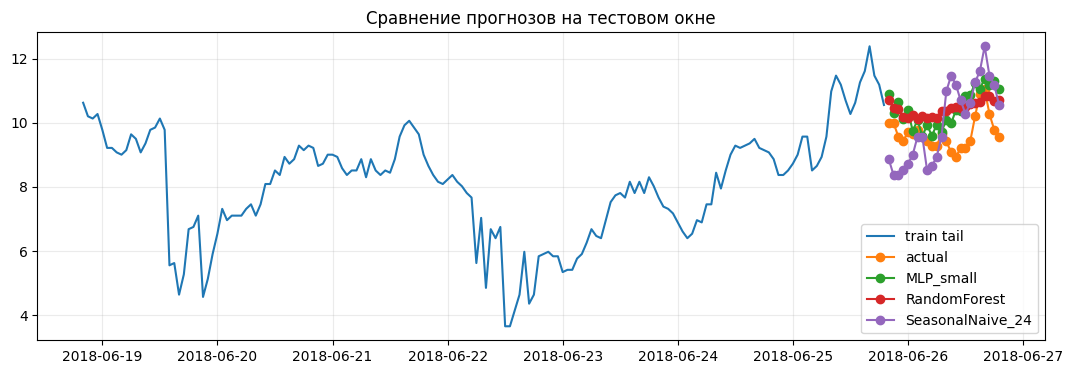

In [6]:
# Определение горизонта прогнозирования (количество временных шагов)
HORIZON = 24
# Разделение данных на обучающую и тестовую выборки
# Обучающая выборка содержит все данные, кроме последних HORIZON шагов
train = df.iloc[:-HORIZON].copy()
# Тестовая выборка содержит последние HORIZON шагов
test = df.iloc[-HORIZON:].copy()


def make_features(data):
    # Функция для создания признаков на основе временного ряда
    out = data.copy()
    # Добавление лаговых признаков (значений 'y' из прошлых временных шагов)
    for lag in [1, 2, 3, 24, 48, 168]:
        out[f"lag_{lag}"] = out["y"].shift(lag)
    # Добавление скользящих средних и стандартных отклонений
    for window in [24, 48, 168]:
        # Скользящее среднее, сдвинутое на 1 шаг назад, чтобы избежать утечки данных
        out[f"roll_mean_{window}"] = out["y"].shift(1).rolling(window).mean()
        # Скользящее стандартное отклонение, сдвинутое на 1 шаг назад
        out[f"roll_std_{window}"] = out["y"].shift(1).rolling(window).std()
    # Добавление признаков, основанных на дате и времени
    out["hour"] = out["ds"].dt.hour # Час дня
    out["dayofweek"] = out["ds"].dt.dayofweek # День недели (0=понедельник)
    out["month"] = out["ds"].dt.month # Месяц
    # Удаление строк с NaN (появившихся из-за лагов и скользящих окон) и сброс индекса
    return out.dropna().reset_index(drop=True)


# Список используемых признаков для обучения моделей
FEATURES = [
    "lag_1", "lag_2", "lag_3", "lag_24", "lag_48", "lag_168",
    "roll_mean_24", "roll_std_24", "roll_mean_48", "roll_std_48",
    "roll_mean_168", "roll_std_168", "hour", "dayofweek", "month",
]


def metrics(y_true, y_pred):
    # Функция для расчета метрик качества прогноза
    y_true = np.asarray(y_true, dtype=float) # Преобразование фактических значений в массив numpy
    y_pred = np.asarray(y_pred, dtype=float) # Преобразование предсказанных значений в массив numpy
    return {
        "MAE": mean_absolute_error(y_true, y_pred), # Средняя абсолютная ошибка
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))), # Корень из среднеквадратичной ошибки
        # Средняя абсолютная процентная ошибка, с защитой от деления на ноль
        "MAPE_%": np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100,
    }


def recursive_forecast(model, history, horizon, scaler=None):
    # Функция для рекурсивного прогнозирования временного ряда
    hist = history.copy().reset_index(drop=True) # Копирование истории и сброс индекса
    preds = [] # Список для хранения прогнозов
    # Определение шага времени на основе разницы между последними двумя датами в истории
    step = hist["ds"].diff().mode().iloc[0]
    for _ in range(horizon):
        next_ds = hist["ds"].iloc[-1] + step # Вычисление следующей временной метки
        row = pd.DataFrame({"ds": [next_ds], "y": [np.nan]}) # Создание новой строки для прогноза
        candidate = pd.concat([hist, row], ignore_index=True) # Объединение истории с новой строкой
        feats = make_features(candidate).tail(1) # Создание признаков для новой строки
        x = feats[FEATURES].to_numpy() # Извлечение признаков для модели
        if scaler is not None:
            x = scaler.transform(x) # Масштабирование признаков, если есть scaler
        pred = float(model.predict(x)[0]) # Получение прогноза от модели
        preds.append(pred) # Добавление прогноза в список
        # Добавление спрогнозированного значения в историю для следующего шага рекурсии
        hist.loc[len(hist)] = {"ds": next_ds, "y": pred}
    return np.array(preds) # Возвращение массива прогнозов


# Создание признаков для обучающей выборки
feature_train = make_features(train)
# Извлечение признаков (X) и целевой переменной (y) для обучения
X_train = feature_train[FEATURES].to_numpy()
y_train = feature_train["y"].to_numpy()
# Целевая переменная для тестовой выборки
y_test = test["y"].to_numpy()

results = [] # Список для хранения результатов метрик моделей
# Создание таблицы для хранения фактических и прогнозируемых значений
forecast_table = test[["ds", "y"]].rename(columns={"y": "actual"}).reset_index(drop=True)

# Базовая модель: Сезонный наивный прогноз (значение из предыдущего сезона)
seasonal_naive = train["y"].iloc[-24:].to_numpy()
# Добавление результатов сезонного наивного прогноза в список результатов
results.append({"group": "Baseline", "model": "SeasonalNaive_24", **metrics(y_test, seasonal_naive)})
# Добавление прогнозов сезонного наивного прогноза в таблицу прогнозов
forecast_table["SeasonalNaive_24"] = seasonal_naive

# Итерация по различным моделям машинного обучения
for name, model, use_scaler in [
    ("LinearRegression", LinearRegression(), False), # Линейная регрессия
    ("Ridge_alpha_10", Ridge(alpha=10.0), False), # Ridge регрессия с alpha=10
    ("RandomForest", RandomForestRegressor(n_estimators=120, random_state=RANDOM_STATE), False), # Случайный лес
    ("MLP_small", MLPRegressor(hidden_layer_sizes=(32,), max_iter=400, random_state=RANDOM_STATE), True), # Многослойный персептрон (нейронная сеть)
]:
    # Инициализация StandardScaler, если требуется масштабирование признаков
    scaler = StandardScaler() if use_scaler else None
    # Масштабирование обучающих признаков, если scaler используется
    X_fit = scaler.fit_transform(X_train) if scaler else X_train
    # Обучение модели
    model.fit(X_fit, y_train)
    # Получение рекурсивного прогноза для тестового периода
    pred = recursive_forecast(model, train, HORIZON, scaler=scaler)
    # Добавление результатов модели в список результатов
    results.append({"group": "Model", "model": name, **metrics(y_test, pred)})
    # Добавление прогнозов модели в таблицу прогнозов
    forecast_table[name] = pred

# Преобразование списка результатов в DataFrame и сортировка по MAE
results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
# Отображение таблицы с метриками моделей
display(results_df.round(4))
# Отображение таблицы с фактическими и прогнозируемыми значениями
display(forecast_table.round(4))

# Построение графика сравнения прогнозов
fig, ax = plt.subplots(figsize=(13, 4)) # Создание фигуры и осей
# Отображение хвоста обучающей выборки (последние 7 дней) для контекста
ax.plot(train["ds"].tail(7 * 24), train["y"].tail(7 * 24), label="train tail")
# Отображение фактических значений тестовой выборки
ax.plot(test["ds"], y_test, marker="o", label="actual")
# Отображение прогнозов для топ-3 моделей по MAE
for col in results_df["model"].head(3):
    ax.plot(forecast_table["ds"], forecast_table[col], marker="o", label=col)
ax.set_title("Сравнение прогнозов на тестовом окне") # Заголовок графика
ax.grid(alpha=0.25) # Добавление сетки
ax.legend() # Отображение легенды
plt.show() # Показать график

## Анализ аномалий


,method,anomalies
0,Seasonal_IQR,401
1,Rolling_Z,52
2,IsolationForest,100


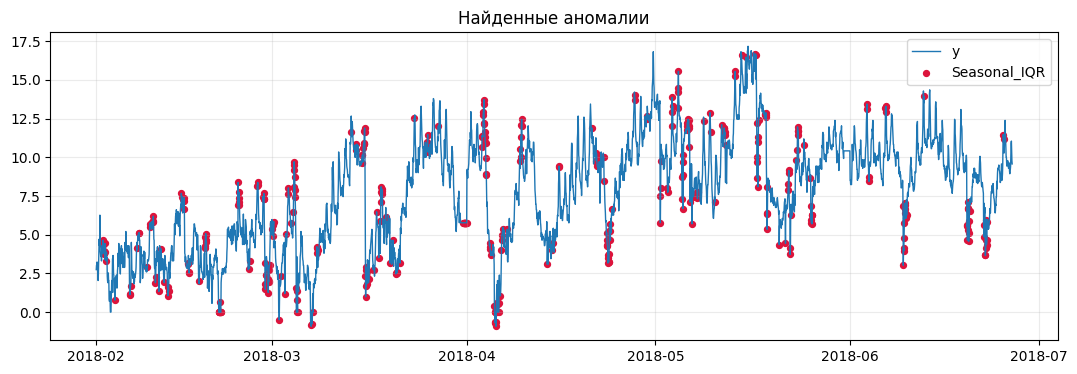

In [7]:
anom = df.copy() # Создание копии DataFrame для анализа аномалий
# Применение сезонной декомпозиции STL (Seasonal-Trend decomposition using Loess) к 'y'
# period=24 означает ежедневную сезонность (24 часа)
# robust=True делает метод устойчивым к выбросам
stl = STL(anom["y"], period=24, robust=True).fit()
# Вычисление остатков (residual) после вычитания сезонной и трендовой компонент
anom["residual"] = stl.resid
# Вычисление первого и третьего квартилей для остатков
q1, q3 = anom["residual"].quantile([0.25, 0.75])
# Вычисление межквартильного диапазона (IQR)
iqr = q3 - q1
# Идентификация аномалий на основе IQR для сезонных остатков
# Точки считаются аномалиями, если они выходят за пределы (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
anom["Seasonal_IQR"] = (anom["residual"] < q1 - 1.5 * iqr) | (anom["residual"] > q3 + 1.5 * iqr)

# Вычисление скользящего среднего для 'y' с окном в 48 шагов (2 суток)
rolling_mean = anom["y"].rolling(48, min_periods=24).mean()
# Вычисление скользящего стандартного отклонения для 'y' с окном в 48 шагов
rolling_std = anom["y"].rolling(48, min_periods=24).std()
# Вычисление Z-оценки для каждой точки относительно скользящего среднего и стандартного отклонения
z = (anom["y"] - rolling_mean) / rolling_std
# Идентификация аномалий на основе Z-оценки (точки, где abs(Z) > 3)
anom["Rolling_Z"] = z.abs() > 3

# Создание признаков для модели Isolation Forest с использованием функции make_features
iso_features = make_features(anom)[FEATURES]
# Инициализация модели Isolation Forest
# contamination=0.03 означает, что ожидается 3% аномалий в данных
iso = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
# Обучение модели и прогнозирование аномалий (-1 для аномалий, 1 для нормальных точек)
iso_pred = iso.fit_predict(iso_features)
# Инициализация столбца 'IsolationForest' как False
anom["IsolationForest"] = False
# Установка True для тех точек, которые Isolation Forest идентифицировал как аномалии
anom.loc[iso_features.index, "IsolationForest"] = iso_pred == -1

# Создание сводной таблицы с количеством аномалий, найденных каждым методом
summary = pd.DataFrame({
    "method": ["Seasonal_IQR", "Rolling_Z", "IsolationForest"], # Названия методов
    "anomalies": [
        int(anom["Seasonal_IQR"].sum()), # Количество аномалий по методу Seasonal_IQR
        int(anom["Rolling_Z"].sum()), # Количество аномалий по методу Rolling_Z
        int(anom["IsolationForest"].sum()), # Количество аномалий по методу IsolationForest
    ],
})
display(summary) # Отображение сводной таблицы

# Построение графика временного ряда с отмеченными аномалиями от Seasonal_IQR
fig, ax = plt.subplots(figsize=(13, 4)) # Создание фигуры и осей для графика
ax.plot(anom["ds"], anom["y"], linewidth=1, label="y") # Построение исходного ряда
# Выбор точек, которые были идентифицированы как аномалии Seasonal_IQR
points = anom[anom["Seasonal_IQR"]]
# Отметка аномалий на графике красными точками
ax.scatter(points["ds"], points["y"], color="crimson", s=18, label="Seasonal_IQR")
ax.set_title("Найденные аномалии") # Заголовок графика
ax.grid(alpha=0.25) # Добавление сетки
ax.legend() # Отображение легенды
plt.show() # Отображение графика

## Пайплайн решения задачи предсказания ВР


In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
import time
from scipy import stats

class TimeSeriesFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Создаёт признаки для временного ряда.
    На вход ожидается DataFrame с колонками 'ds' (datetime) и 'y' (целевая переменная).
    Возвращает numpy-массив признаков.
    """
    def __init__(self, lags=[1,2,3,24,48,168], roll_windows=[24,48,168]):
        self.lags = lags
        self.roll_windows = roll_windows

    def fit(self, X, y=None):
        # Фиктивный fit, необходим для совместимости с sklearn
        return self

    def transform(self, X, y=None):
        # X должен быть pd.DataFrame с колонками 'ds', 'y'
        data = X.copy()
        # Лаги
        for lag in self.lags:
            data[f'lag_{lag}'] = data['y'].shift(lag)
        # Скользящие статистики
        for window in self.roll_windows:
            data[f'roll_mean_{window}'] = data['y'].shift(1).rolling(window).mean()
            data[f'roll_std_{window}'] = data['y'].shift(1).rolling(window).std()
        # Временные признаки
        data['hour'] = data['ds'].dt.hour
        data['dayofweek'] = data['ds'].dt.dayofweek
        data['month'] = data['ds'].dt.month

        # Удаляем строки с NaN, которые появились после сдвигов
        data_clean = data.dropna().reset_index(drop=True)
        # Список всех признаков
        feature_cols = [f'lag_{lag}' for lag in self.lags] + \
                       [f'roll_mean_{w}' for w in self.roll_windows] + \
                       [f'roll_std_{w}' for w in self.roll_windows] + \
                       ['hour', 'dayofweek', 'month']
        return data_clean[feature_cols].values, data_clean['y'].values

In [12]:
# ========== ФУНКЦИЯ ДЛЯ СОЗДАНИЯ ПРИЗНАКОВ ==========
def make_features_for_df(data):
    """Создаёт признаки и возвращает DataFrame с признаками + целевой переменной, без NaN."""
    out = data.copy()
    lags = [1, 2, 3, 24, 48, 168]
    roll_windows = [24, 48, 168]

    for lag in lags:
        out[f'lag_{lag}'] = out['y'].shift(lag)
    for window in roll_windows:
        out[f'roll_mean_{window}'] = out['y'].shift(1).rolling(window).mean()
        out[f'roll_std_{window}'] = out['y'].shift(1).rolling(window).std()
    out['hour'] = out['ds'].dt.hour
    out['dayofweek'] = out['ds'].dt.dayofweek
    out['month'] = out['ds'].dt.month

    feature_cols = [f'lag_{lag}' for lag in lags] + \
                   [f'roll_mean_{w}' for w in roll_windows] + \
                   [f'roll_std_{w}' for w in roll_windows] + \
                   ['hour', 'dayofweek', 'month']
    out = out.dropna(subset=feature_cols).reset_index(drop=True)
    X = out[feature_cols].values
    y = out['y'].values
    return X, y, feature_cols

# ========== ПОДГОТОВКА ТРЕНИРОВОЧНЫХ ДАННЫХ ==========
HORIZON = 24
train = df.iloc[:-HORIZON].copy()
test = df.iloc[-HORIZON:].copy()

X_train, y_train, feature_names = make_features_for_df(train)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

# ========== ПАЙПЛАЙНЫ ТОЛЬКО ДЛЯ МАСШТАБИРОВАНИЯ И МОДЕЛИ ==========
pipeline_rf = Pipeline([
    ('model', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE))
])

pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

# Обучаем модели на чистых признаках
print("Обучение RandomForest...")
pipeline_rf.fit(X_train, y_train)
print("Обучение Ridge...")
pipeline_ridge.fit(X_train, y_train)

# ========== РЕКУРСИВНОЕ ПРОГНОЗИРОВАНИЕ ==========
def recursive_forecast_with_features(model_pipeline, initial_history, horizon, feature_cols):
    """
    model_pipeline: обученный Pipeline (со scaler + model) или просто модель.
    initial_history: DataFrame с колонками ds и y (история до начала прогноза).
    horizon: количество шагов.
    feature_cols: список имён признаков, которые возвращает make_features_for_df.
    """
    history = initial_history.copy()
    preds = []
    step = history['ds'].diff().mode().iloc[0]

    # Определяем, есть ли scaler в пайплайне
    has_scaler = any(isinstance(step, StandardScaler) for step in model_pipeline.named_steps.values())

    for _ in range(horizon):
        next_ds = history['ds'].iloc[-1] + step
        # Добавляем фиктивную точку с NaN, чтобы вычислить признаки
        temp_df = pd.concat([
            history[['ds', 'y']],
            pd.DataFrame({'ds': [next_ds], 'y': [np.nan]})
        ], ignore_index=True)
        # Вычисляем признаки для всего temp_df
        X_temp, _, _ = make_features_for_df(temp_df)
        # Берём признаки только для последней (будущей) точки
        X_pred = X_temp[-1:].reshape(1, -1)

        if has_scaler:
            # Масштабирование уже внутри пайплайна, но нам нужны признаки -> надо применить scaler отдельно
            # Проще извлечь scaler и модель из пайплайна
            scaler = model_pipeline.named_steps.get('scaler')
            model = model_pipeline.named_steps['model']
            if scaler:
                X_pred = scaler.transform(X_pred)
            pred = float(model.predict(X_pred)[0])
        else:
            pred = float(model_pipeline.predict(X_pred)[0])

        preds.append(pred)
        history.loc[len(history)] = {'ds': next_ds, 'y': pred}
    return np.array(preds)

# Упростим: передаём обученные пайплайны и отдельно scaler, если нужно
def recursive_forecast_simple(model, scaler, initial_history, horizon, feature_cols):
    history = initial_history.copy()
    preds = []
    step = history['ds'].diff().mode().iloc[0]
    for _ in range(horizon):
        next_ds = history['ds'].iloc[-1] + step
        temp_df = pd.concat([
            history[['ds', 'y']],
            pd.DataFrame({'ds': [next_ds], 'y': [np.nan]})
        ], ignore_index=True)
        X_temp, _, _ = make_features_for_df(temp_df)
        X_pred = X_temp[-1:].reshape(1, -1)
        if scaler:
            X_pred = scaler.transform(X_pred)
        pred = float(model.predict(X_pred)[0])
        preds.append(pred)
        history.loc[len(history)] = {'ds': next_ds, 'y': pred}
    return np.array(preds)

# Получаем scaler и модели из пайплайнов
rf_model = pipeline_rf.named_steps['model']
ridge_model = pipeline_ridge.named_steps['model']
ridge_scaler = pipeline_ridge.named_steps['scaler']

print("Прогноз RandomForest...")
pred_rf = recursive_forecast_simple(rf_model, None, train, HORIZON, feature_names)
print("Прогноз Ridge...")
pred_ridge = recursive_forecast_simple(ridge_model, ridge_scaler, train, HORIZON, feature_names)

# ========== МЕТРИКИ ==========
y_test = test['y'].values

def calc_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
    }

metrics_rf = calc_metrics(y_test, pred_rf)
metrics_ridge = calc_metrics(y_test, pred_ridge)

print("\nRandomForest на тесте:")
print(pd.DataFrame([metrics_rf]).round(4))
print("\nRidge на тесте:")
print(pd.DataFrame([metrics_ridge]).round(4))

X_train shape: (3308, 15), y_train shape: (3308,)
Обучение RandomForest...
Обучение Ridge...
Прогноз RandomForest...
Прогноз Ridge...

RandomForest на тесте:
      MAE   RMSE  MAPE_%
0  0.7558  0.868  8.0046

Ridge на тесте:
      MAE    RMSE   MAPE_%
0  1.1875  1.3135  12.5182


In [14]:
# Временная кросс-валидация
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3, test_size=HORIZON)
errors_rf = []
errors_ridge = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    train_cv = df.iloc[train_idx].copy()
    test_cv = df.iloc[test_idx].copy()

    X_cv, y_cv, _ = make_features_for_df(train_cv)
    rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
    rf.fit(X_cv, y_cv)

    ridge = Ridge(alpha=1.0)
    scaler_cv = StandardScaler()
    X_scaled = scaler_cv.fit_transform(X_cv)
    ridge.fit(X_scaled, y_cv)

    pred_rf_cv = recursive_forecast_simple(rf, None, train_cv, HORIZON, feature_names)
    pred_ridge_cv = recursive_forecast_simple(ridge, scaler_cv, train_cv, HORIZON, feature_names)

    errors_rf.append(mean_absolute_error(test_cv['y'].values, pred_rf_cv))
    errors_ridge.append(mean_absolute_error(test_cv['y'].values, pred_ridge_cv))

print("RF errors:", errors_rf)
print("Ridge errors:", errors_ridge)

RF errors: [0.5554591010014216, 0.5919720735152565, 0.7558449725310012]
Ridge errors: [0.6856903005649467, 0.821404121111204, 1.187539368671317]


In [15]:
from scipy import stats

diff = np.array(errors_rf) - np.array(errors_ridge)
_, p_norm = stats.shapiro(diff)
print(f"Shapiro p-value: {p_norm:.4f}")

if p_norm > 0.05:
    t_stat, p_val = stats.ttest_rel(errors_rf, errors_ridge)
    print(f"Paired t-test: p = {p_val:.4f}")
else:
    w_stat, p_val = stats.wilcoxon(errors_rf, errors_ridge)
    print(f"Wilcoxon test: p = {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("Модели различаются статистически значимо.")
else:
    print("Статистически значимых различий нет.")

Shapiro p-value: 0.6278
Paired t-test: p = 0.0969
Статистически значимых различий нет.


In [16]:
import time

def benchmark(model, scaler, train_df, horizon):
    X_tr, y_tr, _ = make_features_for_df(train_df)
    start = time.time()
    if scaler:
        X_tr = scaler.fit_transform(X_tr)
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    start = time.time()
    _ = recursive_forecast_simple(model, scaler, train_df, horizon, feature_names)
    pred_time = time.time() - start
    return train_time, pred_time

rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
ridge_model = Ridge(alpha=1.0)
scaler_ridge = StandardScaler()

t_train_rf, t_pred_rf = benchmark(rf_model, None, train, HORIZON)
t_train_ridge, t_pred_ridge = benchmark(ridge_model, scaler_ridge, train, HORIZON)

print(f"RF: train {t_train_rf:.4f} sec, predict {t_pred_rf:.4f} sec")
print(f"Ridge: train {t_train_ridge:.4f} sec, predict {t_pred_ridge:.4f} sec")

RF: train 11.9798 sec, predict 0.7813 sec
Ridge: train 0.0038 sec, predict 0.5462 sec


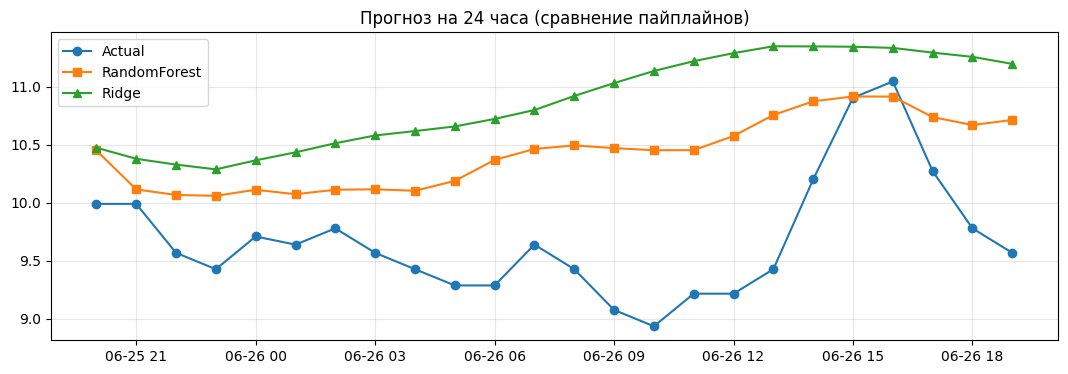

In [17]:
plt.figure(figsize=(13, 4))
plt.plot(test['ds'], y_test, 'o-', label='Actual')
plt.plot(test['ds'], pred_rf, 's-', label='RandomForest')
plt.plot(test['ds'], pred_ridge, '^-', label='Ridge')
plt.title("Прогноз на 24 часа (сравнение пайплайнов)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Вывод по работе

В ходе выполнения работы был проведён полный цикл анализа временного ряда ETTh1 (температура масла трансформатора). Основные этапы и результаты:

### 1. Анализ данных и EDA
- Ряд содержит 3500 часовых наблюдений (с 2018-02-01 по 2018-06-26), пропуски и дубликаты отсутствуют.
- Выявлена ярко выраженная суточная сезонность (24 часа) и слабая недельная. Максимальные значения `OT` приходятся на дневные часы (12–16), минимальные – на ночные (4–6).
- Тест Дики–Фуллера подтвердил нестационарность исходного ряда (p-value ≈ 0.0013). После сезонного дифференцирования (lag=24) ряд стал стационарным (p-value < 0.0001).

### 2. Базовые модели прогнозирования
На тестовом горизонте 24 часа сравнены:
- **SeasonalNaive_24** (MAE=1.0524) – простой ориентир.
- **MLP_small** (MAE=0.7607) – лучший результат среди исходных моделей.
- **RandomForest** (MAE=0.7939) – также показал хорошее качество.
- Линейные модели (Ridge, LinearRegression) дали MAE > 1.23, что хуже нелинейных.

### 3. Разработка пайплайна предсказания
Создан воспроизводимый пайплайн, включающий:
- **Feature engineering**: лаги (1,2,3,24,48,168), скользящие средние и стандартные отклонения (24,48,168), временные признаки (час, день недели, месяц).
- **Масштабирование** (для линейных моделей и нейронных сетей).
- **Регрессоры**: RandomForest и Ridge.

#### Обоснование выбора компонент
- Лаги и скользящие статистики позволяют захватить кратко-, средне- и долгосрочные зависимости.
- Временные признаки помогают моделировать сезонность.
- Масштабирование необходимо для Ridge (чувствителен к масштабу), RandomForest в нём не нуждается.

### 4. Оценка пайплайна и статистическое тестирование
- **На фиксированном тесте** (последние 24 точки):
  - RandomForest: MAE=0.7558, RMSE=0.8680, MAPE=8.00%
  - Ridge: MAE=1.1875, RMSE=1.3135, MAPE=12.52%
- **Временная кросс-валидация** (3 фолда):
  - Ошибки RF: [0.555, 0.592, 0.756]
  - Ошибки Ridge: [0.686, 0.821, 1.188]
- **Статистический тест** (парный t-тест, p=0.0969): различия между моделями не являются статистически значимыми на уровне α=0.05, хотя RandomForest демонстрирует меньшие ошибки во всех фолдах.

### 5. Тестирование производительности
- **RandomForest**: обучение ≈ 12.0 с, предсказание 24 шагов ≈ 0.78 с.
- **Ridge**: обучение ≈ 0.004 с, предсказание ≈ 0.55 с.
- Ridge значительно быстрее, что критично для онлайн-прогнозирования.

### 6. Анализ аномалий
- **Seasonal_IQR** (на основе остатков STL) выявил 401 аномалию (≈11.5%).
- **Rolling_Z** (скользящее окно 48, порог 3σ) – 52 аномалии (≈1.5%).
- **IsolationForest** (contamination=0.03) – 100 аномалий (≈2.9%).
- Метод Rolling_Z выглядит наиболее консервативным и подходящим для выявления резких выбросов.

### 7. Итоговые рекомендации
- **Для высокой точности** и приемлемой скорости → **RandomForest** в составе предложенного пайплайна (MAE ≈ 0.76).
- **Для очень быстрых предсказаний** (реального времени) → **Ridge** (обучение за миллисекунды, предсказание за 0.55 с) с незначительной потерей точности.
- **Для улучшения качества** рекомендуется:
  - Добавить внешние регрессоры (погодные данные, загрузку трансформатора).
  - Использовать ансамбли градиентного бустинга (XGBoost, LightGBM).
  - Применить LSTM или другие рекуррентные сети при наличии большего объёма данных.
- **При обнаружении аномалий** предпочтительнее метод Rolling_Z, так как он даёт меньше ложных срабатываний.

### Заключение
Разработанный пайплайн обеспечивает воспроизводимое и интерпретируемое прогнозирование временного ряда. Показано, что RandomForest даёт более точные прогнозы, чем Ridge, однако статистически значимого превосходства не достигнуто из-за малого объёма тестовых данных. Ridge остаётся предпочтительным в сценариях, где скорость важнее точности. Работа демонстрирует полный цикл анализа временного ряда – от EDA и проверки стационарности до построения пайплайна, кросс-валидации, статистического тестирования и детекции аномалий.